In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [3]:
BASE_PATH = "/content/drive/MyDrive/electricity-load-system"
file_path = f"{BASE_PATH}/data/processed/day2_features.csv"
df = pd.read_csv(file_path, parse_dates=["datetime"])
df.head()

,datetime,Global_active_power,trend_30,day_of_week,rolling_mean_7,rolling_std_7,z_score,anomaly
0,2006-12-16,3.053475,NaN,Saturday,NaN,NaN,NaN,False
1,2006-12-17,2.354486,NaN,Sunday,NaN,NaN,NaN,False
2,2006-12-18,1.530435,NaN,Monday,NaN,NaN,NaN,False
3,2006-12-19,1.157079,NaN,Tuesday,NaN,NaN,NaN,False
4,2006-12-20,1.545658,NaN,Wednesday,NaN,NaN,NaN,False


In [4]:
features = df[
    ["Global_active_power", "rolling_mean_7", "rolling_std_7"]
].dropna()
features.head()

,Global_active_power,rolling_mean_7,rolling_std_7
6,1.625929,1.780117,0.686102
7,3.314851,1.817457,0.769050
8,1.770842,1.734079,0.731863
9,1.904944,1.787580,0.728174
10,2.732021,2.012572,0.744033


In [5]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,   # ~2% anomalies
    random_state=42
)

iso_forest.fit(features)

IsolationForest(contamination=0.02, n_estimators=200, random_state=42)

In [6]:
df.loc[features.index, "iso_anomaly"] = iso_forest.predict(features)

df["iso_anomaly"] = df["iso_anomaly"].map({
    1: 0,
    -1: 1
})

df[["datetime", "Global_active_power", "iso_anomaly"]].head()

,datetime,Global_active_power,iso_anomaly
0,2006-12-16,3.053475,NaN
1,2006-12-17,2.354486,NaN
2,2006-12-18,1.530435,NaN
3,2006-12-19,1.157079,NaN
4,2006-12-20,1.545658,NaN


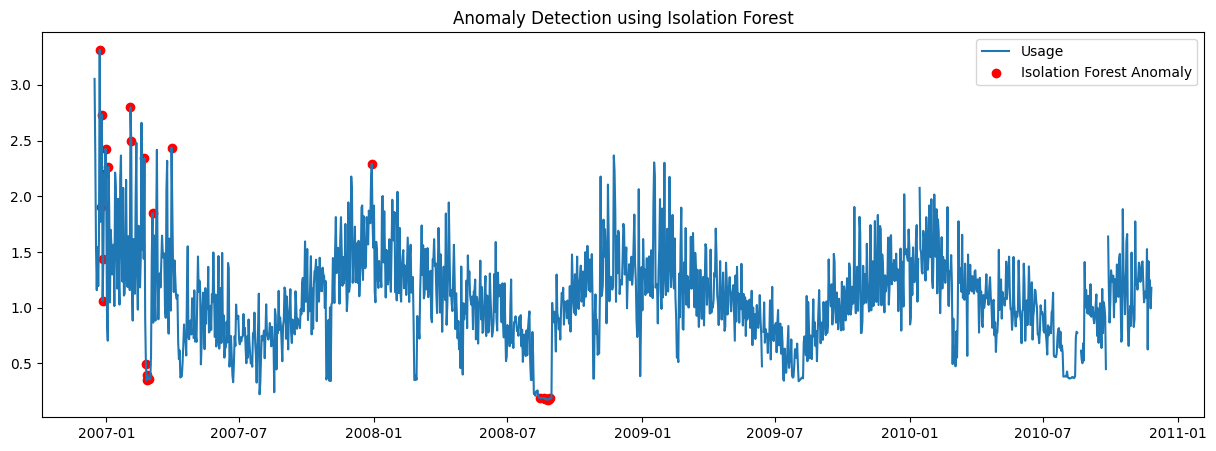

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df["datetime"], df["Global_active_power"], label="Usage")

plt.scatter(
    df[df["iso_anomaly"] == 1]["datetime"],
    df[df["iso_anomaly"] == 1]["Global_active_power"],
    color="red",
    label="Isolation Forest Anomaly"
)

plt.legend()
plt.title("Anomaly Detection using Isolation Forest")
plt.show()

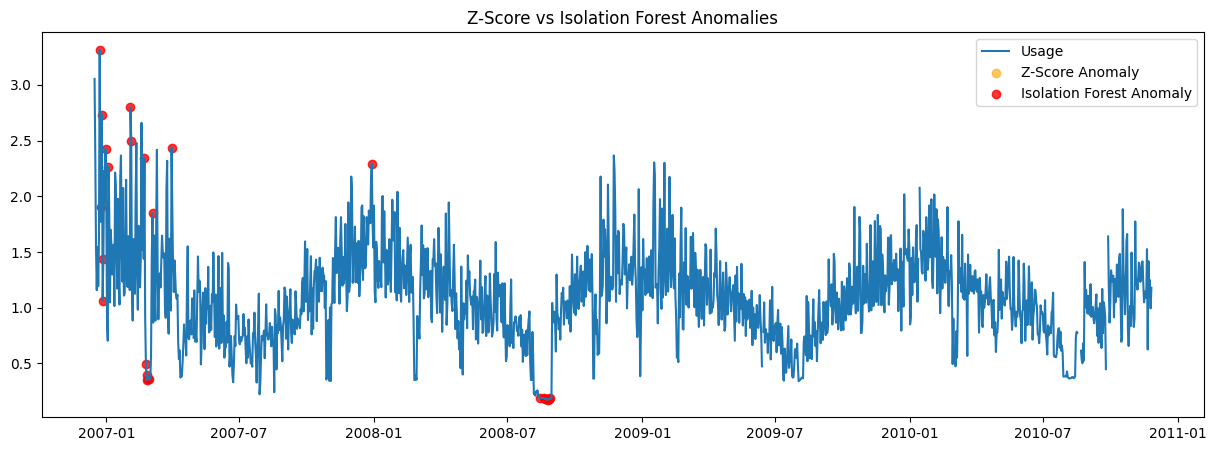

In [8]:
plt.figure(figsize=(15,5))
plt.plot(df["datetime"], df["Global_active_power"], label="Usage")
plt.scatter(
    df[df["anomaly"] == True]["datetime"],
    df[df["anomaly"] == True]["Global_active_power"],
    color="orange",
    label="Z-Score Anomaly",
    alpha=0.6
)
plt.scatter(
    df[df["iso_anomaly"] == 1]["datetime"],
    df[df["iso_anomaly"] == 1]["Global_active_power"],
    color="red",
    label="Isolation Forest Anomaly",
    alpha=0.8
)
plt.legend()
plt.title("Z-Score vs Isolation Forest Anomalies")
plt.show()

In [9]:
df[df["iso_anomaly"] == 1][
    ["datetime", "Global_active_power"]
].head(10)

,datetime,Global_active_power
7,2006-12-23,3.314851
9,2006-12-25,1.904944
10,2006-12-26,2.732021
11,2006-12-27,1.061639
12,2006-12-28,1.439332
13,2006-12-29,2.204439
15,2006-12-31,2.426525
19,2007-01-04,2.263481
49,2007-02-03,2.798418
50,2007-02-04,2.497181


In [10]:
output_path = f"{BASE_PATH}/data/processed/day4_anomalies.csv"

df.to_csv(output_path, index=False)